In [19]:
import os
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
try:
    import cmaps
except ImportError:
    import types
    class _CmapsFallback(types.SimpleNamespace):
        WhiteBlueGreenYellowRed = 'Spectral_r'
        NCV_blu_red = 'RdBu_r'
        def __getattr__(self, name):
            return 'Spectral_r'
    cmaps = _CmapsFallback()
    sys.modules.setdefault('cmaps', cmaps)


# 添加wave_tools到路径
BASE_DIR = '/work/mh1498/m301257'
sys.path.insert(0, BASE_DIR)

from wave_tools.filters import CCKWFilter
from wave_tools.spectral import calculate_wk_spectrum
from wave_tools.plotting import plot_wk_spectrum
from wave_tools.utils import convert_icon_to_latlon_grid, batch_convert_icon_to_latlon
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

from matplotlib.colors import ListedColormap 
myCmap1 = ListedColormap(['#ffffff','#ffffc7','#fff98e','#ffd556','#ff9c1d','#e36400','#a92a00','#710500','#380000','#000000'])
from Xianpumap import plot_hovmoller
from Xianpumap import plot_data_lat,plot_data_lon
print(f" 工作目录: {BASE_DIR}")

 工作目录: /work/mh1498/m301257


In [2]:
ds = xr.open_dataset(r'/work/mh1498/m301257/processed_data_lat_30/2d_layers/pr_cntl/pr_2deg_interp.nc')
ds

<xarray.Dataset> Size: 273MB
Dimensions:  (time: 5114, lat: 37, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 296B -36.0 -34.0 -32.0 -30.0 ... 30.0 32.0 34.0 36.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    pr       (time, lat, lon) float64 272MB ...

In [3]:
ds.attrs

{}

In [4]:
wave_filter = CCKWFilter(
            ds=ds['pr']*86400,  # 转换为mm/day
            sel_dict={"lat": slice(-20, 20)},
            wave_name='kelvin',
            units='mm/day',
            spd=1,
            n_workers=3,
            verbose=True,
            n_harm=3,
        )
wave = wave_filter.process()

🌊 Processing KELVIN wave filter

==================== Loaded Data Information ====================
Type: <class 'xarray.core.dataarray.DataArray'>
Shape: (5114, 21, 180)
Data type: float64
First few values: <xarray.DataArray 'pr' (time: 5, lat: 21, lon: 180)> Size: 151kB
array([[[3.48063111e-01, 4.48942934e-01, 2.38413317e-01, ...,
         7.29085754e-01, 1.26156045e+00, 1.50576890e+00],
        [1.08908644e-01, 2.67539034e-01, 5.73225349e-01, ...,
         2.16686013e-01, 2.82993299e-01, 5.25720083e-01],
        [8.93876911e-01, 1.51304508e-01, 3.75683829e-01, ...,
         3.13437617e-01, 3.21516997e-03, 9.88136122e-02],
        ...,
        [2.45618997e-13, 1.11564892e-13, 1.48924099e-13, ...,
         7.41810180e-12, 3.29455333e-12, 1.46370124e-13],
        [1.94522247e-12, 9.20416131e-15, 0.00000000e+00, ...,
         6.90028820e-12, 7.29147987e-12, 4.88142681e-12],
        [3.75889255e-12, 2.68644353e-12, 4.23009743e-13, ...,
         2.07926013e-12, 3.44349592e-12, 2.29379294e-

In [5]:
wave

<xarray.DataArray (time: 5114, lat: 21, lon: 180)> Size: 155MB
array([[[-0.04860245, -0.10998755, -0.15869355, ...,  0.1219261 ,
          0.07758486,  0.01731691],
        [ 0.18461941,  0.12618043,  0.06805439, ...,  0.28618537,
          0.27137348,  0.23554217],
        [-0.01672038, -0.01074252, -0.00535451, ..., -0.02252182,
         -0.02344196, -0.02134924],
        ...,
        [-0.34525927, -0.32385965, -0.28546327, ..., -0.31114537,
         -0.33674932, -0.34906872],
        [ 0.25435758,  0.24069437,  0.20153449, ...,  0.14567356,
          0.20276789,  0.24094282],
        [ 0.1186284 ,  0.10644795,  0.0923341 , ...,  0.12769176,
          0.13065896,  0.12724625]],

       [[ 0.14866327,  0.11841209,  0.06014037, ...,  0.05270633,
          0.11104481,  0.14570278],
        [ 0.30947881,  0.29598713,  0.26356274, ...,  0.23132078,
          0.27475355,  0.30207309],
        [ 0.06453194,  0.06544027,  0.0738269 , ...,  0.07863974,
          0.07491675,  0.06886921],
...
        [-0.00798558, -0.02346199, -0.02947058, ...,  0.06534382,
          0.04138302,  0.01503342],
        [-0.18140833, -0.19754932, -0.18937076, ..., -0.00594362,
         -0.0792773 , -0.14055525],
        [-0.20652294, -0.25397224, -0.29850299, ..., -0.09081361,
         -0.12256035, -0.16152744]],

       [[-0.16343022, -0.17665814, -0.17837491, ..., -0.06236822,
         -0.104589  , -0.13903554],
        [-0.03489045, -0.06871849, -0.08680254, ...,  0.14619068,
          0.07726956,  0.01482903],
        [ 0.02166273,  0.04144009,  0.05663878, ..., -0.03356529,
         -0.01767744,  0.0010849 ],
        ...,
        [ 0.02278468,  0.06424814,  0.09321882, ..., -0.15173125,
         -0.08913493, -0.0294448 ],
        [ 0.06065859, -0.02532262, -0.1063508 , ...,  0.24175353,
          0.20334584,  0.1403629 ],
        [ 0.05543708,  0.02951458, -0.00283111, ...,  0.11325602,
          0.09569595,  0.07684341]]], shape=(5114, 21, 180))
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 168B -20.0 -18.0 -16.0 -14.0 ... 14.0 16.0 18.0 20.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes: (12/15)
    long_name:               kelvin wave filtered data
    min_equiv_depth:         8.0
    max_equiv_depth:         90.0
    min_wavenumber:          1
    max_wavenumber:          14
    min_period:              2.5
    ...                      ...
    units:                   mm/day
    filter_method:           NCL-aligned Wheeler-Kiladis kf_filter
    processing_date:         2026-06-05
    samples_per_day:         1
    annual_cycle_harmonics:  3
    backend_wave_name:       kelvin

In [6]:
WESTERN_PACIFIC_EXTENT = [0, 360, -30, 30]

from Xianpumap import plot_western_pacific_basemap
data = wave.var('time')


In [7]:
def _turn_off_cartopy_ticks(ax):
    ax.tick_params(labelsize=15, direction='out', top=False, right=False)
    # 1. 关掉投影轮廓
    try:
        ax.spines['geo'].set_visible(False)
    except KeyError:
        ax.outline_patch.set_visible(False)

    from matplotlib.lines import Line2D

    # 关闭 geo 轮廓
    try:
        ax.spines['geo'].set_visible(False)
    except KeyError:
        ax.outline_patch.set_visible(False)
    plt.draw()  # 先触发渲染，让 cartopy 生成所有 tick

    # 关闭顶部和右侧的 tick 线
    ax.xaxis.set_tick_params(top=False, which='both')
    ax.yaxis.set_tick_params(right=False, which='both')
    # 左边线
    ax.add_artist(Line2D([0, 0], [0, 1], transform=ax.transAxes,
                        color='black', linewidth=1.5, clip_on=False))
    # 底边线
    ax.add_artist(Line2D([0, 1], [0, 0], transform=ax.transAxes,
                        color='black', linewidth=1.5, clip_on=False))

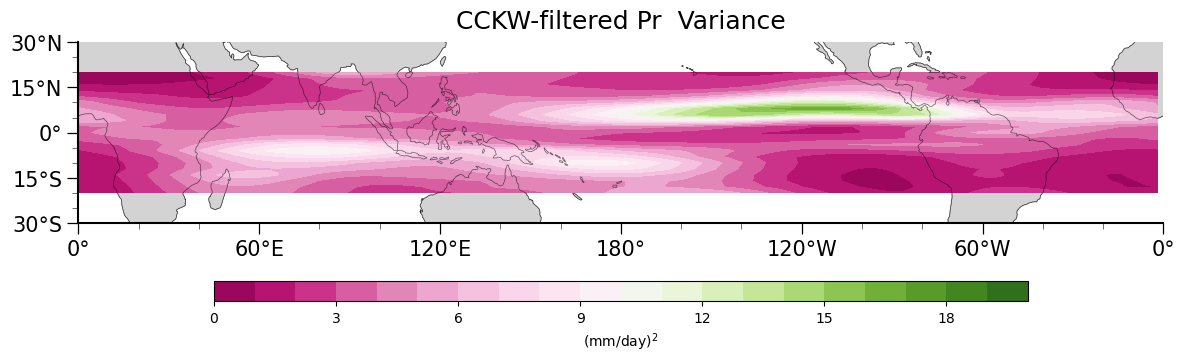

In [8]:

fig, ax = plot_western_pacific_basemap(
    extent=WESTERN_PACIFIC_EXTENT,
    central_lon=180,
    figsize=(14, 7.5),
    title="",
    use_geocat=True,
    show_labels=True,
    add_reference_lines=False,
    land_facecolor="lightgray",
    coastline_color="gray",
    basename="western_pacific_basemap_provided_style",
    save=False,
)
im = ax.contourf(
    data.lon.values, data.lat.values, data.values,
    levels=np.linspace(0, 20, 21),
    cmap='PiYG',
    vmin=0, vmax=20,
    transform=ccrs.PlateCarree(),
    extend='neither',
)

_turn_off_cartopy_ticks(ax)

ax.set_title('CCKW-filtered Pr  Variance', pad=10, fontsize=18)

cbar1 = fig.colorbar(im, ax=ax, orientation='horizontal',
                     pad=0.1, shrink=0.75, aspect=40, label=r'(mm/day)$^2$')

### Meridional evolution of zonal-mean standard deviation of CCKW

In [9]:
def seasonal_cycle(pre):
    
    precip_clim = (
    pre
    .groupby("time.month")
    .var(dim="time"))

    return precip_clim


In [10]:
wave_seasonal_cycle = seasonal_cycle(wave)
wave_seasonal_cycle

<xarray.DataArray (month: 12, lat: 21, lon: 180)> Size: 363kB
array([[[2.29463678, 2.48185404, 2.68961344, ..., 1.86334139,
         1.98397502, 2.1282765 ],
        [2.07635368, 2.20724335, 2.37402504, ..., 1.80805613,
         1.88702325, 1.97322933],
        [2.82619783, 3.0951161 , 3.40376329, ..., 2.20699837,
         2.38558909, 2.59112278],
        ...,
        [0.28269888, 0.2759634 , 0.26885789, ..., 0.30241752,
         0.29525467, 0.28898943],
        [0.23314121, 0.22689298, 0.22131477, ..., 0.25850422,
         0.24860296, 0.24026854],
        [0.21356458, 0.21526235, 0.21827172, ..., 0.21712978,
         0.21403478, 0.21309375]],

       [[2.03099153, 2.1652443 , 2.33614949, ..., 1.78451086,
         1.84606163, 1.92666682],
        [2.4589838 , 2.6685598 , 2.91713585, ..., 2.05772202,
         2.15250185, 2.28648754],
        [2.63931501, 2.81938274, 3.02209406, ..., 2.17335169,
         2.31848366, 2.47384867],
...
        [0.61430039, 0.61329996, 0.61556055, ..., 0.65378453,
         0.63299072, 0.62031107],
        [0.46004626, 0.44962842, 0.44144066, ..., 0.51200744,
         0.48981222, 0.47302622],
        [0.4039177 , 0.4005671 , 0.39898562, ..., 0.43313626,
         0.41901091, 0.40965851]],

       [[1.77451753, 1.84198898, 1.92948849, ..., 1.69983407,
         1.70275684, 1.72775288],
        [1.52052982, 1.60867974, 1.71798359, ..., 1.37040264,
         1.4025624 , 1.45225884],
        [2.13413443, 2.28409735, 2.46401369, ..., 1.83904488,
         1.91461502, 2.01196962],
        ...,
        [0.35632261, 0.35246999, 0.34951413, ..., 0.37823529,
         0.36863843, 0.36152558],
        [0.3113912 , 0.31327607, 0.31625305, ..., 0.31513364,
         0.31201945, 0.31090241],
        [0.26764451, 0.26092336, 0.2564194 , ..., 0.3020712 ,
         0.28771998, 0.27643565]]], shape=(12, 21, 180))
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 168B -20.0 -18.0 -16.0 -14.0 ... 14.0 16.0 18.0 20.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes: (12/15)
    long_name:               kelvin wave filtered data
    min_equiv_depth:         8.0
    max_equiv_depth:         90.0
    min_wavenumber:          1
    max_wavenumber:          14
    min_period:              2.5
    ...                      ...
    units:                   mm/day
    filter_method:           NCL-aligned Wheeler-Kiladis kf_filter
    processing_date:         2026-06-05
    samples_per_day:         1
    annual_cycle_harmonics:  3
    backend_wave_name:       kelvin

In [11]:
zonalmean_wave_seasonal_cycle = wave_seasonal_cycle.sel(lat=slice(-15, 15)).mean(dim=['lon'])
time    = zonalmean_wave_seasonal_cycle.month.values
time
lat     = zonalmean_wave_seasonal_cycle.lat.values
lat

array([-14., -12., -10.,  -8.,  -6.,  -4.,  -2.,   0.,   2.,   4.,   6.,
         8.,  10.,  12.,  14.])

(<matplotlib.contour.QuadContourSet at 0x7f8b1df70ef0>,
 <Axes: title={'left': 'Evolution of CCKW-filtered'}>)

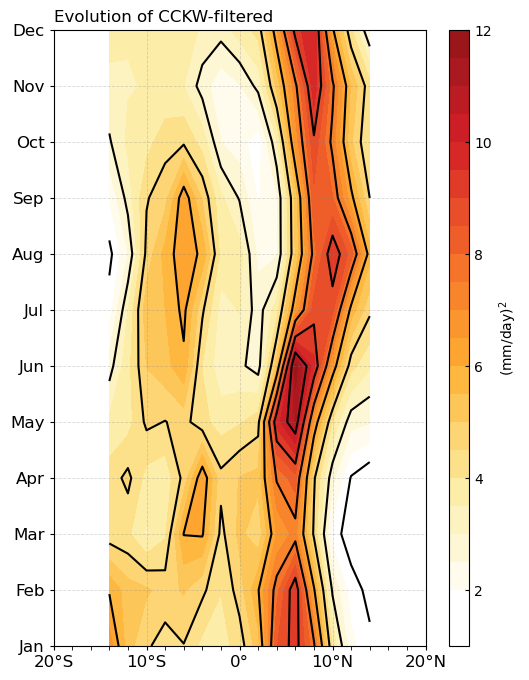

In [ ]:
def makefig_lon(ax,title,box,newcmap=cmaps.WhiteBlueGreenYellowRed,):
    xstep,ystep = 45,5
    ax.set_xticks(np.linspace(box[0], box[1], xstep),)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(60))
    ax.xaxis.set_minor_locator(mticker.AutoMinorLocator(5))
    ax.xaxis.set_major_formatter(LongitudeFormatter())

    ax.set_title(title,loc='left',fontsize=20)
    ax.set_title(r'',loc='right')
    ax.tick_params(which='major',length=5)
    return ax


def makefig_lat(ax,title,box):

    xstep,ystep = 8,5

    ax.set_xticks(np.linspace(box[2], box[3], ystep),)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
    ax.xaxis.set_minor_locator(mticker.AutoMinorLocator(5))
    ax.xaxis.set_major_formatter(LatitudeFormatter())

    ax.set_title(title,loc='left')
    ax.set_title(r'',loc='right')
    ax.tick_params(which='major',length=5)
    # ax.set_aspect(20)

    return ax

def plot_data_lat( data,ax, cmap,  fmt, y_labels, y_ticks, 
              title, box, clabel_conditions,subfig=None,
              ):
    


    f = ax.contourf(lat,time,data,
                            cmap=cmaps.BlueWhiteOrangeRed[128:],
                            levels=21,
                            # extend='both',
                            # add_colorbar=True
                            )
    ax.contour(lat,time,data,colors='k',linewidth=0.8)
    ax.grid(linestyle='--', color='gray', alpha=0.3, linewidth=0.6)
    ax.set_ylim(1,12)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    if subfig==True:

        ax = makefig_lon(ax, title, box)
    elif subfig==False:
        ax = makefig_lat(ax, title, box)  
        cbar = plt.colorbar(f, shrink=1, aspect=30, label=r'(mm/day)$^2$',
                            ticks=np.arange(0.,20,2))
        ax.tick_params(which='both',direction='out',length=3,labelsize=12)
        cbar.ax.tick_params(which='both',direction='in',length=3,labelsize=10)
    else:
        ax = makefig_lat(ax, title, box)  
        cbar = plt.colorbar(f,
                            ticks=np.arange(0.,10,0.2)
                            )
        cbar.ax.tick_params(which='both',direction='in',length=3)
    return f, ax
color_string = '''
#BF1E06
#CF2E0F
#DF3F1A
#EC5126
#F16334
#F28C57
#F3AF7A
#F5CB9B
#F8E2BD
#FBF3DD
#FFFEFD
''' 
fmt = '%.1f'
# cmap = create_cmap_from_string(color_string)
cmap = cmaps.WhiteBlueGreenYellowRed
bins = [0.5,0.8,1,1.2,1.4,1.6,1.8,2,2.2,2.4,2.8]



month_labels = ['Dec', 'Nov', 'Oct', 'Sep', 'Aug', 'Jul', 
                'Jun', 'May', 'Apr', 'Mar', 'Feb', 'Jan'][::-1]
fig = plt.figure(figsize=(6, 8))
grid = fig.add_gridspec(ncols=1, nrows=1)
ax1 = fig.add_subplot(grid[0, 0])
box_obs = [0, 360, -20, 20]
plot_data_lat(zonalmean_wave_seasonal_cycle, ax1, cmap,  fmt, month_labels, np.arange(1, 13),
              title='Evolution of CCKW-filtered', box=box_obs,
              clabel_conditions=('1.2', '1.6', '2', '2.4'),subfig=False)

In [13]:
meridonmean_wave_seasonal_cycle = wave_seasonal_cycle.sel(lat=slice(-15, 15)).mean(dim=['lat'])
lon = meridonmean_wave_seasonal_cycle.lon.values
lon

array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
        22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
        44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
        66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
        88.,  90.,  92.,  94.,  96.,  98., 100., 102., 104., 106., 108.,
       110., 112., 114., 116., 118., 120., 122., 124., 126., 128., 130.,
       132., 134., 136., 138., 140., 142., 144., 146., 148., 150., 152.,
       154., 156., 158., 160., 162., 164., 166., 168., 170., 172., 174.,
       176., 178., 180., 182., 184., 186., 188., 190., 192., 194., 196.,
       198., 200., 202., 204., 206., 208., 210., 212., 214., 216., 218.,
       220., 222., 224., 226., 228., 230., 232., 234., 236., 238., 240.,
       242., 244., 246., 248., 250., 252., 254., 256., 258., 260., 262.,
       264., 266., 268., 270., 272., 274., 276., 278., 280., 282., 284.,
       286., 288., 290., 292., 294., 296., 298., 30

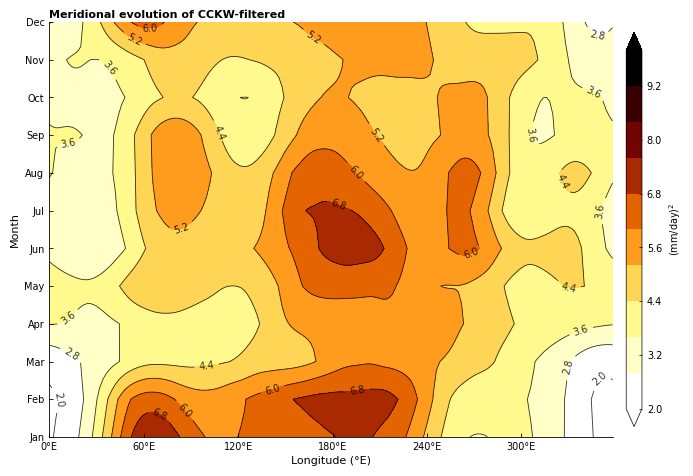

In [14]:
fig, ax = plot_hovmoller(
    lon,
    time,
    meridonmean_wave_seasonal_cycle,
    title='Meridional evolution of CCKW-filtered',
    cbar_label='(mm/day)$^2$',
    cmap=myCmap1,
)
ax.xaxis.set_major_locator(mticker.MultipleLocator(60))

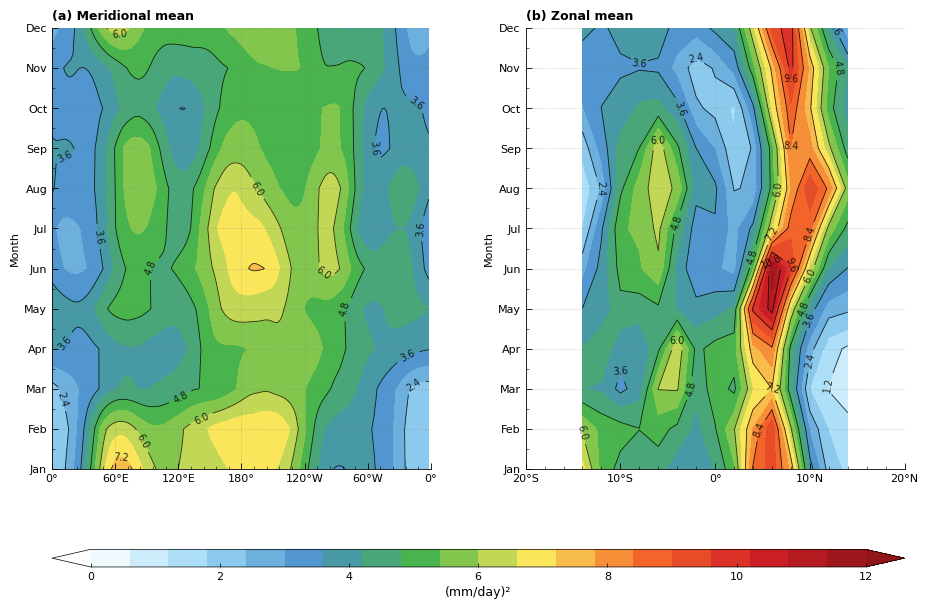

In [24]:
import matplotlib.gridspec as gridspec

# ── 1. 统一数据范围 ───────────────────────────────────────────────────────────
shared_levels = np.linspace(0, 12, 21)   # 或自动计算：
# vmin = min(data1.min(), data2.min())
# vmax = max(data1.max(), data2.max())
# shared_levels = np.linspace(vmin, vmax, 21)

# ── 2. 布局：主图区 + colorbar 行 ─────────────────────────────────────────────
fig = plt.figure(figsize=(11, 7))
gs  = gridspec.GridSpec(
    nrows=2, ncols=2,
    height_ratios=[1, 0.04],   # 主图 : colorbar 高度比
    hspace=0.35,               # 主图与 cbar 之间的间距
    wspace=0.25,
)

ax1  = fig.add_subplot(gs[0, 0])
ax2  = fig.add_subplot(gs[0, 1])
cax  = fig.add_subplot(gs[1, :])   # 横跨两列的 colorbar 轴

# ── 3. 绘图（传入统一 levels，关闭各自 cbar）────────────────────────────────
cf1, _ = plot_data_lon(
    meridonmean_wave_seasonal_cycle, ax1, fig,
    lon=lon.data, time=time,
    cmap=cmaps.WhiteBlueGreenYellowRed,
    levels=shared_levels,
    title='(a) Meridional mean',
    box=box_obs,
    add_cbar=False,
)
cf2, _ = plot_data_lat(
    zonalmean_wave_seasonal_cycle, ax2, fig,
    lat=lat, time=time,
    cmap=cmaps.WhiteBlueGreenYellowRed,   # 同一 cmap 才能共享
    levels=shared_levels,
    title='(b) Zonal mean',
    box=box_obs,
    add_cbar=False,
)

# ── 4. 水平 colorbar，放在 cax 上 ────────────────────────────────────────────
cbar = fig.colorbar(
    cf1,                        # cf1 与 cf2 levels 相同，用哪个都行
    cax=cax,
    orientation='horizontal',
)
cbar.set_label('(mm/day)²', fontsize=9, labelpad=3)
cbar.ax.tick_params(
    which='both', direction='in',
    length=3, width=0.5, labelsize=8,
)
cbar.outline.set_linewidth(0.5)

# 可选：自定义 colorbar 刻度
cbar.set_ticks(np.arange(0, 13, 2))